In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from src.data.comtrade_client import collect_russia_trade

In [ ]:
# 데이터 수집 — 수집 로직은 src/data/comtrade_client.py 참조
reporters = {
    "Armenia": "51",
    "Kazakhstan": "398",
    "Georgia": "268",
    "Turkey": "792",
    "UAE": "784",
}

all_df = collect_russia_trade(
    reporters=reporters,
    hs_codes="7210,8542",
    years=list(range(2020, 2025)),
)

all_df.to_csv("comtrade_monthly_2020_2024_russia_7210_8542.csv", index=False)
all_df.head()

  -> no data or error for UAE, 2020
  -> no data or error for UAE, 2021
  -> no data or error for UAE, 2022
  -> no data or error for UAE, 2023
  -> no data or error for UAE, 2024


/tmp/ipykernel_24256/1860518593.py:54: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_df = pd.concat(all_list, ignore_index=True)


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate,reporterName
0,C,M,20200101,2020,1,202001,51,ARM,Armenia,M,...,False,0.0,False,56506.22,0.0,56506.22,0,False,True,Armenia
1,C,M,20200101,2020,1,202001,51,ARM,Armenia,M,...,False,0.0,False,18534.50,0.0,18534.50,0,False,True,Armenia
2,C,M,20200101,2020,1,202001,51,ARM,Armenia,M,...,False,0.0,False,37971.72,0.0,37971.72,0,False,True,Armenia
3,C,M,20200101,2020,1,202001,51,ARM,Armenia,M,...,False,0.0,False,7247.08,0.0,7247.08,0,False,True,Armenia
4,C,M,20200101,2020,1,202001,51,ARM,Armenia,M,...,False,0.0,False,5757.83,0.0,5757.83,0,False,True,Armenia


In [14]:
#전처리
#raw data 시계열 분석 가능하게
#HS 7210, 8542만 남김
#연도와 월을 합쳐 날짜 컬럼 생성
#나라·품목·수출입·월 기준으로 월별 총액 집계
ts = all_df[all_df["cmdCode"].isin(["7210", "8542"])].copy()

ts["date"] = pd.to_datetime(
    ts["refYear"].astype(str) + "-" + ts["refMonth"].astype(str) + "-01"
)

ts_group = (
    ts.groupby(["reporterDesc", "cmdCode", "flowCode", "date"])["primaryValue"]
      .sum()
      .reset_index()
)

ts_group.head()

,reporterDesc,cmdCode,flowCode,date,primaryValue
0,Armenia,7210,M,2020-01-01,226024.88
1,Armenia,7210,M,2020-02-01,90224.80
2,Armenia,7210,M,2020-03-01,154475.28
3,Armenia,7210,M,2020-04-01,581198.08
4,Armenia,7210,M,2020-05-01,9634769.96


In [15]:
#기본 타임시리즈 그래프
#나라별 월별 수출 추이를 그림
#2022년 2월 제재 시점을 세로선으로 표시
#제재 전후 변화가 시각적으로 드러나게 함

#1. 제재 전에는 거의 없었는가

#2. 제재 후 급증했는가

#3. 어떤 나라가 가장 강하게 튀는가 -> 이 세개 보기


def plot_trade_series(ts_group, hs_code="8542", flow="X", title_suffix="exports to Russia"):
    plot_df = ts_group[
        (ts_group["cmdCode"] == hs_code) &
        (ts_group["flowCode"] == flow)
    ]

    plt.figure(figsize=(10, 5))
    for name, g in plot_df.groupby("reporterDesc"):
        plt.plot(g["date"], g["primaryValue"], label=name)

    plt.axvline(pd.to_datetime("2022-02-01"), color="red", linestyle="--", label="Sanctions start")
    plt.title(f"HS {hs_code} {title_suffix} by reporter")
    plt.ylabel("USD")
    plt.legend()
    plt.tight_layout()
    plt.show()

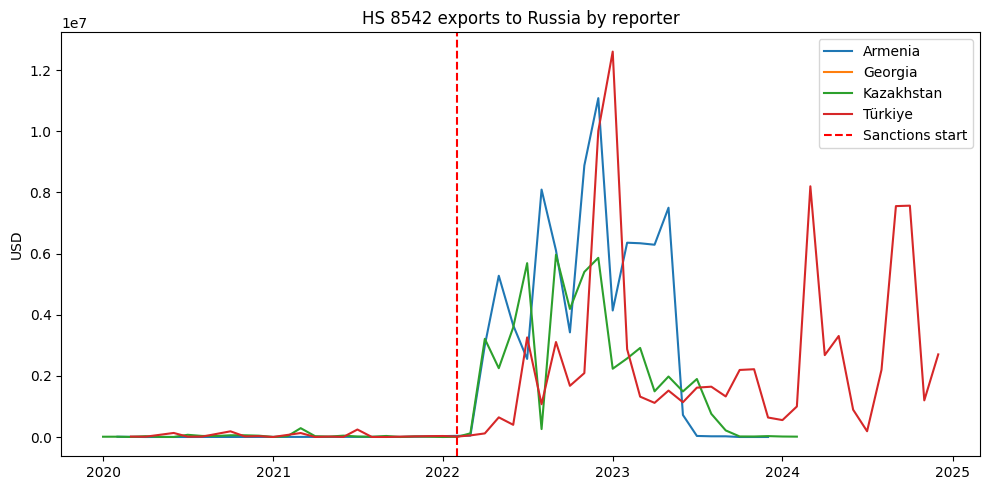

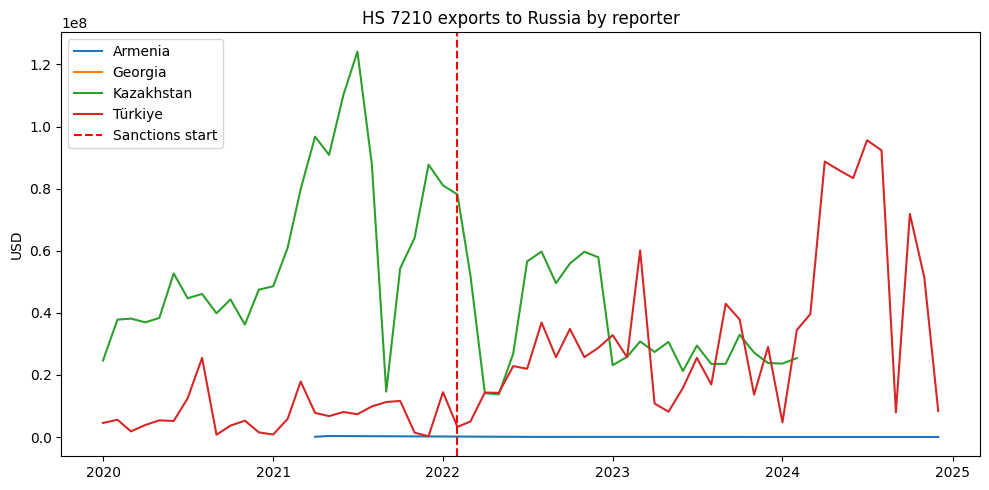

In [16]:
plot_trade_series(ts_group, hs_code="8542", flow="X")
plot_trade_series(ts_group, hs_code="7210", flow="X")

In [17]:
#제재 전후 평균 비교
#수출(flowCode="X")만 따로 봄
#제재 전과 후로 나눔
#각 나라·품목별 월평균 수출액을 계산
#제재 후가 제재 전보다 몇 배인지 ratio 계산


ts_x = all_df[
    (all_df["cmdCode"].isin(["7210", "8542"])) &
    (all_df["flowCode"] == "X")
].copy()

ts_x["date"] = pd.to_datetime(
    ts_x["refYear"].astype(str) + "-" + ts_x["refMonth"].astype(str) + "-01"
)

ts_x["period_group"] = ts_x["date"].apply(
    lambda d: "pre" if d < pd.to_datetime("2022-02-01") else "post"
)

summary = (
    ts_x.groupby(["reporterDesc", "cmdCode", "period_group"])["primaryValue"]
        .mean()
        .reset_index()
)

summary_pivot = summary.pivot_table(
    index=["reporterDesc", "cmdCode"],
    columns="period_group",
    values="primaryValue"
).fillna(0)

summary_pivot["post_pre_ratio"] = (
    (summary_pivot["post"] + 1) / (summary_pivot["pre"] + 1)
)

summary_pivot = summary_pivot.reset_index()
summary_pivot.sort_values(["cmdCode", "post_pre_ratio"], ascending=[True, False])

period_group,reporterDesc,cmdCode,post,pre,post_pre_ratio
2,Georgia,7210,6.781940e+04,0.000000e+00,67820.400000
6,Türkiye,7210,3.271997e+06,6.977729e+05,4.689195
4,Kazakhstan,7210,2.177596e+07,2.038785e+07,1.068085
0,Armenia,7210,3.868163e+03,5.097535e+04,0.075901
3,Georgia,8542,2.491960e+03,0.000000e+00,2492.960000
1,Armenia,8542,1.006057e+06,1.079193e+03,931.369466
5,Kazakhstan,8542,1.043092e+06,1.319637e+04,79.037979
7,Türkiye,8542,1.730069e+05,4.623510e+03,37.411076


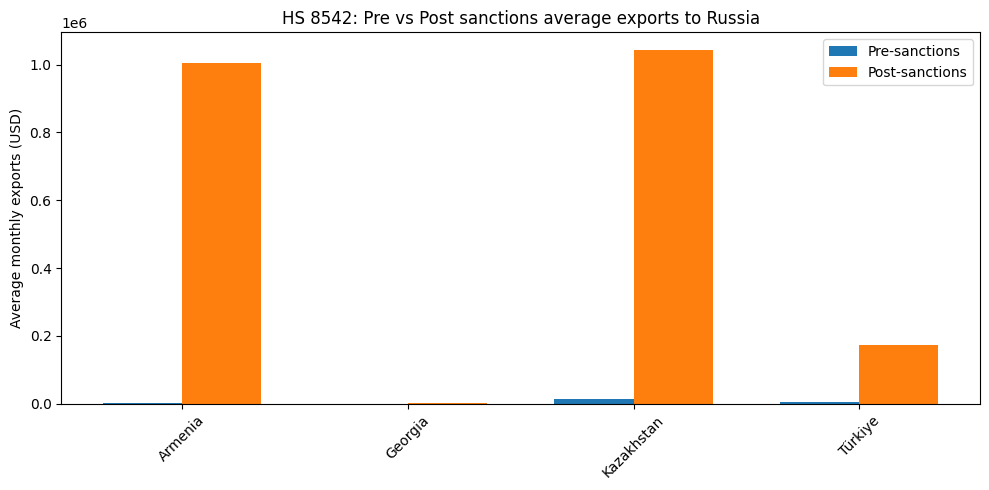

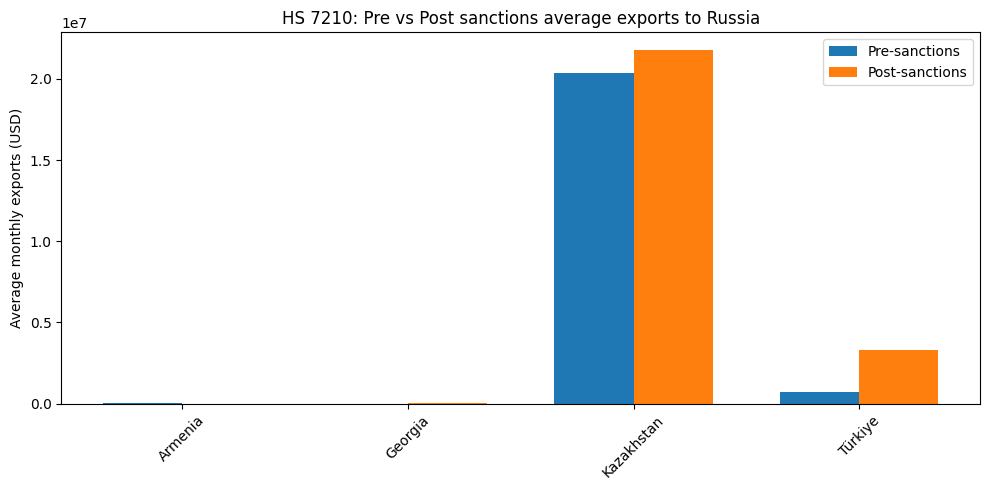

In [18]:
#막대 그래프 요약
#제재 전 평균과 후 평균을 한 눈에 비교
#어느 나라가 가장 크게 부상했는지 빠르게 전달
import numpy as np

for hs in ["8542", "7210"]:
    temp = summary_pivot[summary_pivot["cmdCode"] == hs].copy()

    x = np.arange(len(temp))
    width = 0.35

    plt.figure(figsize=(10,5))
    plt.bar(x - width/2, temp["pre"], width, label="Pre-sanctions")
    plt.bar(x + width/2, temp["post"], width, label="Post-sanctions")

    plt.xticks(x, temp["reporterDesc"], rotation=45)
    plt.ylabel("Average monthly exports (USD)")
    plt.title(f"HS {hs}: Pre vs Post sanctions average exports to Russia")
    plt.legend()
    plt.tight_layout()
    plt.show()

###분석용 체크포인트

HS 8542에서 누가 가장 크게 증가했는가

HS 7210에서 누가 가장 크게 증가했는가

제재 전부터 크던 나라와, 제재 후 새로 튄 나라가 구분되는가

UAE처럼 결측이나 서버 오류가 있는 국가는 어떻게 처리할 것인가

In [19]:
# 1. 누가 가장 크게 증가했는가
summary_pivot["abs_increase"] = summary_pivot["post"] - summary_pivot["pre"]

# HS 8542
summary_8542 = summary_pivot[summary_pivot["cmdCode"] == "8542"].copy()
summary_8542_ratio = summary_8542.sort_values("post_pre_ratio", ascending=False)
summary_8542_abs = summary_8542.sort_values("abs_increase", ascending=False)

# HS 7210
summary_7210 = summary_pivot[summary_pivot["cmdCode"] == "7210"].copy()
summary_7210_ratio = summary_7210.sort_values("post_pre_ratio", ascending=False)
summary_7210_abs = summary_7210.sort_values("abs_increase", ascending=False)

print("HS 8542 - ratio 기준")
display(summary_8542_ratio[["reporterDesc", "pre", "post", "post_pre_ratio", "abs_increase"]])

print("HS 8542 - 절대증가 기준")
display(summary_8542_abs[["reporterDesc", "pre", "post", "post_pre_ratio", "abs_increase"]])

print("HS 7210 - ratio 기준")
display(summary_7210_ratio[["reporterDesc", "pre", "post", "post_pre_ratio", "abs_increase"]])

print("HS 7210 - 절대증가 기준")
display(summary_7210_abs[["reporterDesc", "pre", "post", "post_pre_ratio", "abs_increase"]])

HS 8542 - ratio 기준


period_group,reporterDesc,pre,post,post_pre_ratio,abs_increase
3,Georgia,0.000000,2.491960e+03,2492.960000,2.491960e+03
1,Armenia,1079.192500,1.006057e+06,931.369466,1.004978e+06
5,Kazakhstan,13196.369062,1.043092e+06,79.037979,1.029896e+06
7,Türkiye,4623.510204,1.730069e+05,37.411076,1.683834e+05


HS 8542 - 절대증가 기준


period_group,reporterDesc,pre,post,post_pre_ratio,abs_increase
5,Kazakhstan,13196.369062,1.043092e+06,79.037979,1.029896e+06
1,Armenia,1079.192500,1.006057e+06,931.369466,1.004978e+06
7,Türkiye,4623.510204,1.730069e+05,37.411076,1.683834e+05
3,Georgia,0.000000,2.491960e+03,2492.960000,2.491960e+03


HS 7210 - ratio 기준


period_group,reporterDesc,pre,post,post_pre_ratio,abs_increase
2,Georgia,0.000000e+00,6.781940e+04,67820.400000,6.781940e+04
6,Türkiye,6.977729e+05,3.271997e+06,4.689195,2.574224e+06
4,Kazakhstan,2.038785e+07,2.177596e+07,1.068085,1.388105e+06
0,Armenia,5.097535e+04,3.868163e+03,0.075901,-4.710718e+04


HS 7210 - 절대증가 기준


period_group,reporterDesc,pre,post,post_pre_ratio,abs_increase
6,Türkiye,6.977729e+05,3.271997e+06,4.689195,2.574224e+06
4,Kazakhstan,2.038785e+07,2.177596e+07,1.068085,1.388105e+06
2,Georgia,0.000000e+00,6.781940e+04,67820.400000,6.781940e+04
0,Armenia,5.097535e+04,3.868163e+03,0.075901,-4.710718e+04


In [21]:
# 제재 전부터 크던 나라 vs 제재 후 새로 튄 나라 구분
#제재 전부터 크던 나라: 원래 러시아와 거래가 많던 기존 허브
#제재 후 새로 튄 나라: 제재 이후 새롭게 부상한 우회 허브 가능성
def classify_country(row, pre_threshold, ratio_threshold):
    if row["pre"] >= pre_threshold and row["post"] >= pre_threshold:
        return "제재 전부터 큰 국가"
    elif row["pre"] < pre_threshold and row["post_pre_ratio"] >= ratio_threshold:
        return "제재 후 새로 튄 국가"
    else:
        return "중간/혼합형"

# 예시 threshold: 데이터 규모 보고 조정
summary_pivot["group_type"] = summary_pivot.apply(
    lambda row: classify_country(row, pre_threshold=1_000_000, ratio_threshold=3),
    axis=1
)

display(summary_pivot[["reporterDesc", "cmdCode", "pre", "post", "post_pre_ratio", "group_type"]]
        .sort_values(["cmdCode", "post_pre_ratio"], ascending=[True, False]))

period_group,reporterDesc,cmdCode,pre,post,post_pre_ratio,group_type
2,Georgia,7210,0.000000e+00,6.781940e+04,67820.400000,제재 후 새로 튄 국가
6,Türkiye,7210,6.977729e+05,3.271997e+06,4.689195,제재 후 새로 튄 국가
4,Kazakhstan,7210,2.038785e+07,2.177596e+07,1.068085,제재 전부터 큰 국가
0,Armenia,7210,5.097535e+04,3.868163e+03,0.075901,중간/혼합형
3,Georgia,8542,0.000000e+00,2.491960e+03,2492.960000,제재 후 새로 튄 국가
1,Armenia,8542,1.079193e+03,1.006057e+06,931.369466,제재 후 새로 튄 국가
5,Kazakhstan,8542,1.319637e+04,1.043092e+06,79.037979,제재 후 새로 튄 국가
7,Türkiye,8542,4.623510e+03,1.730069e+05,37.411076,제재 후 새로 튄 국가


###UAE처럼 결측/서버 오류 국가는 어떻게 처리하나


경우 1. 서버 오류로 못 받은 경우
재호출(retry) 먼저 한다.

그래도 안 되면 missing_due_to_api_error로 표시한다.

경우 2. 진짜 데이터가 없는 경우
0 또는 no trade로 해석 가능

하지만 API 결과와 메타데이터를 보고 판단해야 함.

경우 3. UAE처럼 여러 해가 연속 결측인 경우
메인 결과 해석에서는 제외하거나

“해석 보류”로 따로 표시하는 게 좋다

In [24]:
ts_group["reporterDesc"] = ts_group["reporterDesc"].replace({
    "Türkiye": "Turkey"
})

In [25]:
expected = pd.MultiIndex.from_product(
    [
        ["Armenia", "Kazakhstan", "Georgia", "Turkey", "UAE"],
        ["7210", "8542"],
        ["X"],  # 우선 수출 기준
        pd.date_range("2020-01-01", "2024-12-01", freq="MS")
    ],
    names=["reporterDesc", "cmdCode", "flowCode", "date"]
)

actual = ts_group[
    ts_group["flowCode"] == "X"
][["reporterDesc", "cmdCode", "flowCode", "date"]].drop_duplicates()

missing_check = (
    pd.DataFrame(index=expected)
      .reset_index()
      .merge(actual.assign(observed=1),
             on=["reporterDesc", "cmdCode", "flowCode", "date"],
             how="left")
)

missing_summary = (
    missing_check.groupby(["reporterDesc", "cmdCode"])["observed"]
    .apply(lambda x: x.isna().sum())
    .reset_index(name="missing_months")
    .sort_values(["cmdCode", "missing_months"], ascending=[True, False])
)

display(missing_summary)

,reporterDesc,cmdCode,missing_months
8,UAE,7210,60
2,Georgia,7210,59
0,Armenia,7210,51
4,Kazakhstan,7210,10
6,Turkey,7210,0
9,UAE,8542,60
3,Georgia,8542,59
1,Armenia,8542,32
5,Kazakhstan,8542,10
7,Turkey,8542,5


러시아 제재 이후 HS 8542와 HS 7210의 대러 수출 패턴은 상이한 양상을 보였다. HS 8542에서는 Armenia, Kazakhstan, Türkiye가 모두 제재 후 신규 급증국으로 분류되었으며, 특히 Armenia는 제재 전 월평균 수출액이 거의 존재하지 않았음에도 제재 후 약 100만 달러 수준으로 확대되어 가장 강한 증가세를 나타냈다. Kazakhstan 역시 제재 후 월평균 수출액이 약 104만 달러 수준으로 증가하여 상대적 증가율과 절대 규모 모두에서 핵심 경유국 후보로 확인되었다. 반면 HS 7210에서는 Kazakhstan이 제재 이전부터 이미 큰 대러 수출 규모를 유지한 기존 중심국으로 나타났으며, Türkiye는 제재 이후 가장 뚜렷하게 부상한 국가로 확인되었다.이는 반도체류에서는 제재 이후 신규 우회 허브가 형성된 반면, 철강류에서는 기존 무역 네트워크 위에 새로운 부상국이 추가되는 방식으로 우회 또는 대체 무역이 전개되었을 가능성을 시사한다.

또한 국가별 결측 개월 수를 함께 검토한 결과, Türkiye와 Kazakhstan은 비교적 해석 신뢰도가 높은 반면, Georgia와 UAE는 결측이 과도하게 많아 핵심 결론에 포함하기 어렵다. 특히 UAE는 전 기간 결측이 확인되어 본 분석의 핵심 해석에서는 제외하였으며, Georgia는 소규모 증가가 관찰되더라도 보조 사례 수준에서만 언급하는 것이 적절하다.